In [12]:
import pandas as pd
import os
import glob
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
def force_clean_id(x):
    if isinstance(x, dict) and '$oid' in x:
        return x['$oid']
    return str(x)

In [14]:
file_path = ".\\Shiksha_Copilot_DB\\schools.json"
collection = glob.glob(os.path.join(file_path))

file = open(file_path, "r", encoding='utf-8', errors='ignore')
tempRead = file.readline()
sample_doc = json.loads(tempRead)
schema = list(sample_doc.keys())
file.seek(0)

for s in schema:
    print(s)

_id
name
schoolId
type
boards
state
zone
district
block
mediums
academicYearStartDate
academicYearEndDate
isDeleted
facilities
holidayList
createdAt
updatedAt
__v


In [15]:
schools_list = []
for line in file:
    schools_list.append(json.loads(line))

schools = pd.DataFrame(schools_list)
print(schools)

                                       _id  \
0     {'$oid': '6707c215864af0671e0e37d3'}   
1     {'$oid': '6707c215864af0671e0e37db'}   
2     {'$oid': '6707c215864af0671e0e37e3'}   
3     {'$oid': '6707c215864af0671e0e37ec'}   
4     {'$oid': '6707c215864af0671e0e37f4'}   
...                                    ...   
5913  {'$oid': '6995870b9e9ea9c858a7f763'}   
5914  {'$oid': '6995877b9e9ea9c858a7fc39'}   
5915  {'$oid': '699588be9e9ea9c858a805f4'}   
5916  {'$oid': '6995894e9e9ea9c858a806a4'}   
5917  {'$oid': '699589bd9e9ea9c858a80754'}   

                                                 name      schoolId   type  \
0                           GOVT- HIGH SCHOOL ACHANUR  2.902020e+10  urban   
1                   GOVT- HIGH SCHOOL BODANAYAKADINNI  2.902020e+10  urban   
2               GOVT- KB HIGHER PRIMARY SCHOOL CHABBI  2.902020e+10  urban   
3     GOVT- KB HIGHER PRIMARY SCHOOL CHIKKASHELLIKERI  2.902020e+10  urban   
4              GOVT-  HIGHER PRIMARY SCHOOL CHOUDAPUR  2.

In [16]:
#Exploring school information gleaned from names, no explicit fields on gender segregation, grade levels are present
gender_info = {
    "Boys_Only" : [],
    "Girls_Only" : [],
    "Co-ed": []
}

grade_level = {
    "Higher_Primary" : [],
    "High_School": [],
    "Combined": []
}

for index, row in schools.iterrows():
    temp_name = row["name"].lower()
    
    if "boys" in temp_name:
        gender_info["Boys_Only"].append(row)
    elif "girls" in temp_name:
        gender_info["Girls_Only"].append(row)
    else:
        gender_info["Co-ed"].append(row)
    
    if "primary" in temp_name and "high school" not in temp_name:
        grade_level["Higher_Primary"].append(row)
    elif "high school" in temp_name and 'primary' not in temp_name:
        grade_level["High_School"].append(row)
    else:
        grade_level["Combined"].append(row)

In [17]:
print(f"Boys-Only Schools: {len(gender_info['Boys_Only'])} \n"
      f"Girls-Only Schools: {len(gender_info['Girls_Only'])} \n" 
      f"Presumably Co-ed Schools: {len(gender_info['Co-ed'])}")

Boys-Only Schools: 103 
Girls-Only Schools: 173 
Presumably Co-ed Schools: 5642


In [18]:
print(f"Primary Schools: {len(grade_level['Higher_Primary'])} \n"
      f"High Schools: {len(grade_level['High_School'])} \n" 
      f"Presumably Combined Schools: {len(grade_level['Combined'])}")

Primary Schools: 1153 
High Schools: 358 
Presumably Combined Schools: 4407


In [19]:
#schools with empty facilities entries

schools_wData = []
for index, row in schools.iterrows(): 
    if len(row["facilities"])!=0: 
        schools_wData.append([row["name"], row["_id"]['$oid'], row['district'], row['block']])

for i in schools_wData: print(i) #Only 8 schools have any information about their facilities at all

['GHS RMSA BEERAVALLI', '68cb93276d5be54ec049856a', 'Dharwad', 'Kalghatagi']
['GHPS CCI Main Gate Kurakunta', '69157a0b42e56548b7c96225', 'Kalburgi', 'Sedam']
['GHPS Mathodu', '692180e7d48fba59cac7c3f8', 'Chitradurga', 'Hosadurga']
['GHPS Barasidlahalli', '6924070dd48fba59cacf6baf', 'Tumakuru', 'Chiknayakanhalli']
['GHS J B HALLI', '6929b24399e9770ab960b575', 'Chitradurga', 'Molakalmur']
['GLPS GOLLARAHATTI ( Kodlahalli)', '692a82e599e9770ab96182be', 'Chitradurga', 'Molakalmur']
['G  H P S GORBAL ', '692ad9c299e9770ab96d4d9f', 'Bagalkot', 'Hunagund']
['HPS NO2 Haveri', '6949582ac0fd6d3c04030c70', 'Haveri', 'Haveri']


In [20]:
#schools counts separated by medium
medium_info = {
    "English" : [],
    "Kannada" : [],
    "Both" : []
}

for index, row in schools.iterrows():
    mediums = row["mediums"]
    
    if len(mediums)==1 and "English" in mediums:
        medium_info["English"].append(row)
    elif "Kannada" in mediums:
        medium_info["Kannada"].append(row)
    else:
        medium_info["Both"].append(row)

In [21]:
sections = pd.DataFrame([json.loads(line) for line in open(".\\Shiksha_Copilot_DB\\classes.json", "r", encoding='utf-8', errors='ignore')])
for index, row in sections.iterrows():
    print(row)
    break


_id                          {'$oid': '6707c215864af0671e0e37d5'}
board                                                       KSEEB
medium                                                    english
start                                                           5
end                                                            10
classDetails    [{'_id': {'$oid': '69673ff41de46ae630b52c81'},...
schoolId                     {'$oid': '6707c215864af0671e0e37d3'}
isDeleted                                                   False
createdAt                   {'$date': '2024-10-10T12:01:25.789Z'}
updatedAt                   {'$date': '2024-10-10T12:01:25.789Z'}
__v                                                           0.0
Name: 0, dtype: object


In [44]:
users = pd.DataFrame([json.loads(line) for line in open(".\\Shiksha_Copilot_DB\\users.json", "r", encoding='utf-8', errors='ignore')])
lessonChats = pd.DataFrame([json.loads(line) for line in open(".\\Shiksha_Copilot_DB\\lessonchats.json", "r", encoding='utf-8', errors='ignore')])
questionBankInfo = pd.DataFrame([json.loads(line) for line in open(".\\Shiksha_Copilot_DB\\questionbankconfigurations.json", "r", encoding='utf-8', errors='ignore')])

for i in [users, lessonChats, questionBankInfo]:
    cols = i.columns
    print(f"Schema: {list(cols)}\n")

Schema: ['_id', 'name', 'state', 'zone', 'district', 'block', 'phone', 'role', 'school', 'preferredLanguage', 'facilities', 'isProfileCompleted', 'profileImage', 'isDeleted', 'classes', 'createdAt', 'updatedAt', '__v', 'profileImageExpiresIn', 'isLoginAllowed', 'rememberMeToken', 'otp']

Schema: ['_id', 'teacherId', 'recordId', 'message', 'createdAt', 'updatedAt', '__v']

Schema: ['_id', 'teacherId', 'board', 'medium', 'grade', 'subject', 'examinationName', 'chapterIds', 'topics', 'isMultiChapter', 'totalMarks', 'marksDistribution', 'objectiveDistribution', 'questionBankTemplate', 'bluePrintTemplate', 'questionBank', 'createdAt', 'updatedAt', '__v']



In [47]:
user_map = users[['_id', 'school', 'district', 'zone']].copy()
user_map['teacher_key'] = user_map['_id'].apply(force_clean_id)
user_map['school_key'] = user_map['school'].apply(force_clean_id)

lessonChats['teacher_key'] = lessonChats['teacherId'].apply(force_clean_id)
questionBankInfo['teacher_key'] = questionBankInfo['teacherId'].apply(force_clean_id)

chat_counts = lessonChats.groupby('teacher_key').size().reset_index(name='chat_count')
qb_counts = questionBankInfo.groupby('teacher_key').size().reset_index(name='qb_count')

teacher_activity = user_map.merge(chat_counts, on='teacher_key', how='left')
teacher_activity = teacher_activity.merge(qb_counts, on='teacher_key', how='left')

unique_zones = teacher_activity['zone'].unique()

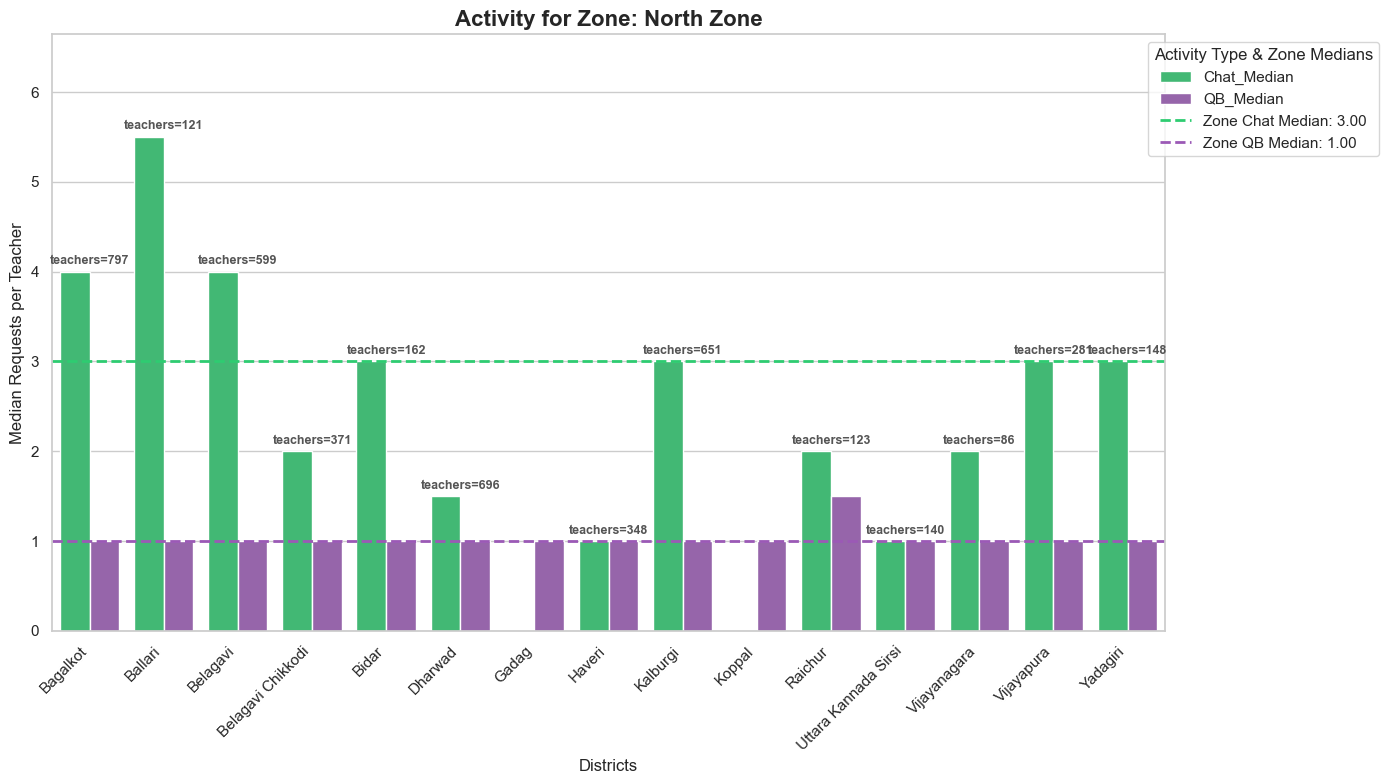

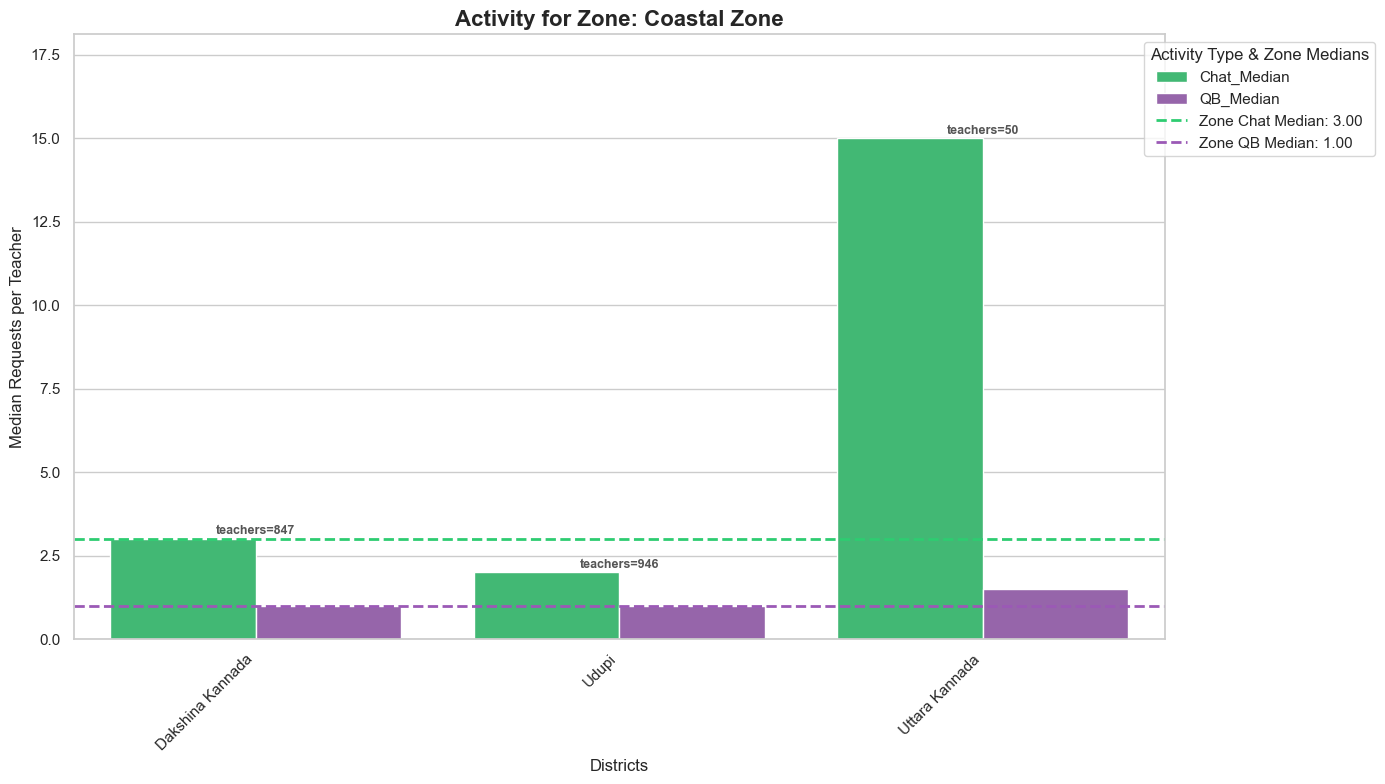

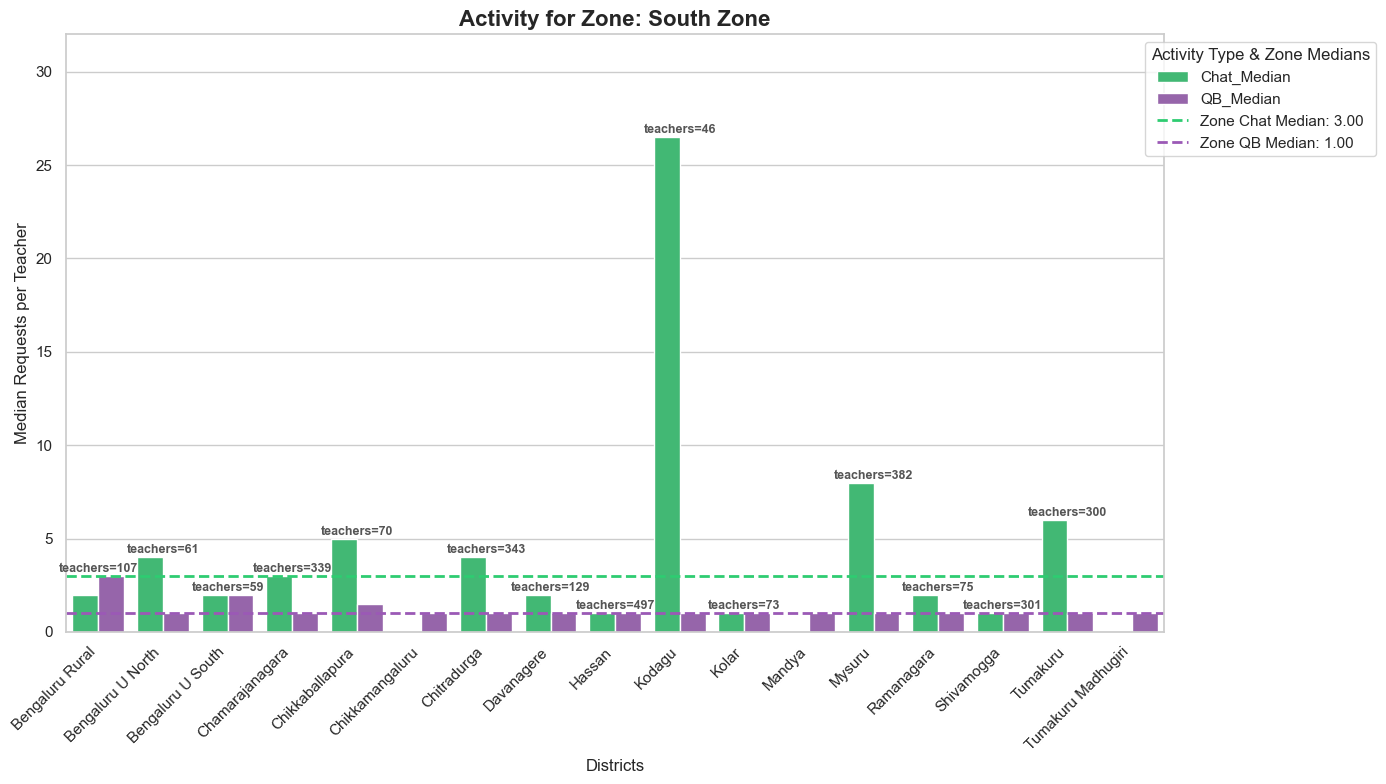

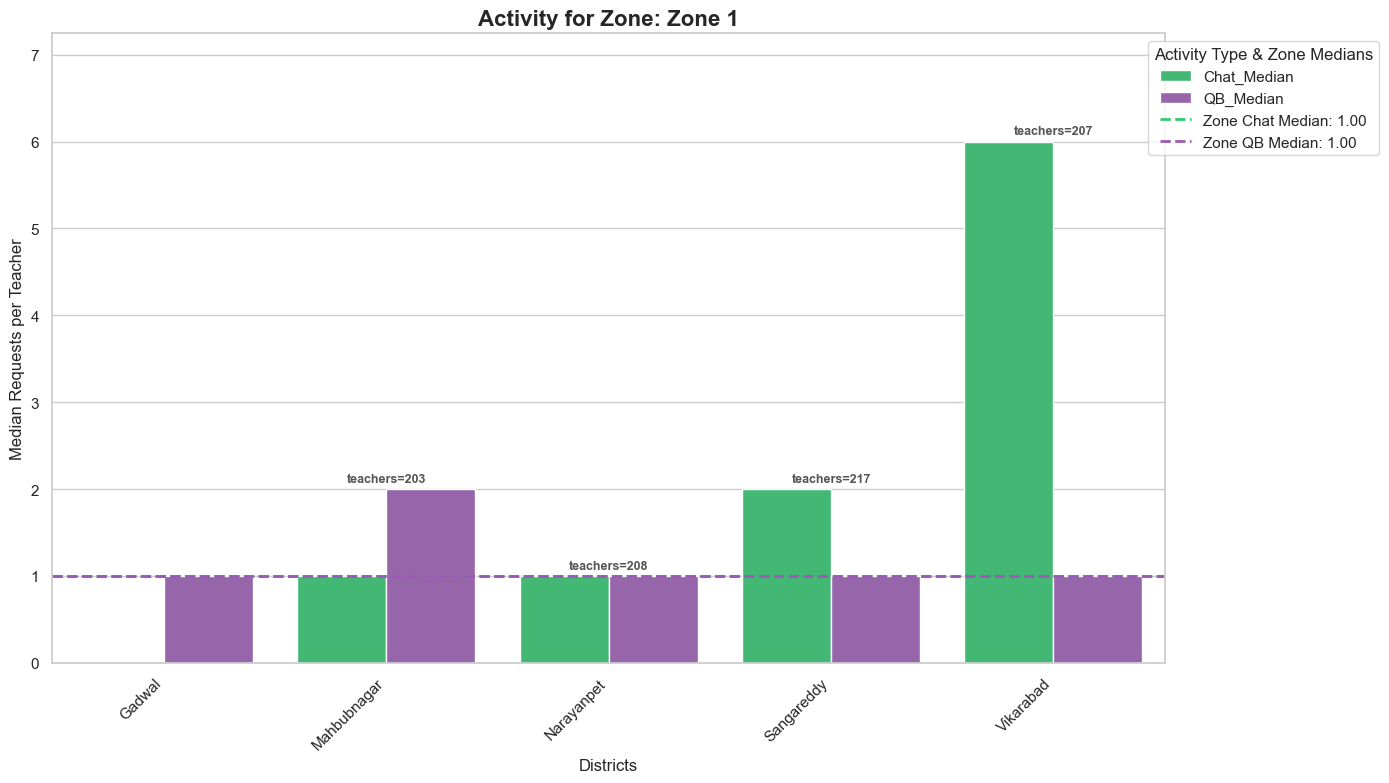

In [48]:
sns.set_theme(style="whitegrid")
unique_zones = teacher_activity['zone'].unique()

for zone in unique_zones:
    zone_data = teacher_activity[teacher_activity['zone'] == zone]
    
    zone_chat_median = zone_data['chat_count'].median()
    zone_qb_median = zone_data['qb_count'].median()
    
    district_summary = zone_data.groupby('district').agg({
        'chat_count': 'median',
        'qb_count': 'median',
        'teacher_key': 'nunique'
    }).reset_index()
    
    district_summary.columns = ['district', 'Chat_Median', 'QB_Median', 'teacher_count']
    
    plot_data = district_summary.melt(
        id_vars=['district', 'teacher_count'], 
        value_vars=['Chat_Median', 'QB_Median'], 
        var_name='Activity_Type', 
        value_name='Median_Requests'
    )
    
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        data=plot_data, 
        x='district', 
        y='Median_Requests', 
        hue='Activity_Type', 
        palette=['#2ecc71', '#9b59b6'] 
    )
    
    ax.axhline(y=zone_chat_median, color='#2ecc71', linestyle='--', linewidth=2, label=f'Zone Chat Median: {zone_chat_median:.2f}')
    ax.axhline(y=zone_qb_median, color='#9b59b6', linestyle='--', linewidth=2, label=f'Zone QB Median: {zone_qb_median:.2f}')

    for i, row in district_summary.iterrows():
        max_val = max(row['Chat_Median'], row['QB_Median'])
        ax.text(i, max_val + 0.05, f'teachers={row["teacher_count"]}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='#555555')

    plt.title(f'Activity for Zone: {zone}', fontsize=16, fontweight='bold')
    plt.xlabel('Districts', fontsize=12)
    plt.ylabel('Median Requests per Teacher', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.legend(title='Activity Type & Zone Medians', loc='upper right', bbox_to_anchor=(1.2, 1))
    
    plt.ylim(0, plt.gca().get_ylim()[1] * 1.15)
    plt.tight_layout()
    plt.show()

identify which schools in kodagu and UK are power users.
Identify state and zone-wise median usage stats and identify usages.

question quality, per district info
